In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
X_train = np.load("data/X_part1.npy")
X_val = np.load("data/X_val_part1.npy")
y_val = np.load("data/y_val_part1.npy")

In [3]:
print ('X_train:', X_train.shape)
print ('X_val:', X_val.shape)
print ('y_val: ', y_val.shape)

X_train: (307, 2)
X_val: (307, 2)
y_val:  (307,)


In [8]:
print('X_train:', X_train[:5])

X_train: [[13.04681517 14.74115241]
 [13.40852019 13.7632696 ]
 [14.19591481 15.85318113]
 [14.91470077 16.17425987]
 [13.57669961 14.04284944]]


In [4]:
print('X_val:', X_train[:5])

X_val: [[13.04681517 14.74115241]
 [13.40852019 13.7632696 ]
 [14.19591481 15.85318113]
 [14.91470077 16.17425987]
 [13.57669961 14.04284944]]


In [10]:
print('y_val:', X_train[:5])

y_val: [[13.04681517 14.74115241]
 [13.40852019 13.7632696 ]
 [14.19591481 15.85318113]
 [14.91470077 16.17425987]
 [13.57669961 14.04284944]]


(np.float64(0.0), np.float64(30.0), np.float64(0.0), np.float64(30.0))

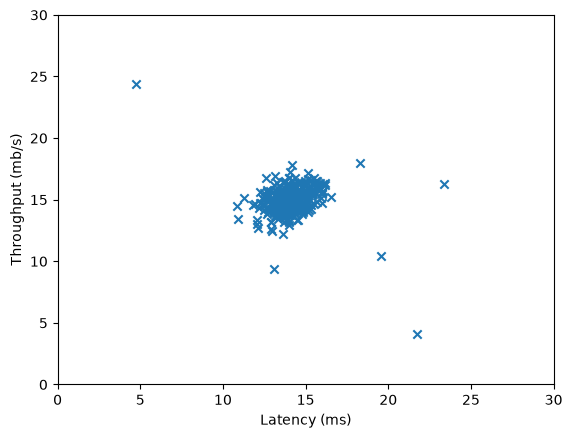

In [5]:
plt.scatter(X_train[:,0], X_train[:,1], marker='x')
plt.ylabel('Throughput (mb/s)')
plt.xlabel('Latency (ms)')
plt.axis([0, 30, 0, 30])

In [6]:


def estimate_gaussian(X): 
    """
    Calculates mean and variance of all features 
    in the dataset
    
    Args:
        X (ndarray): (m, n) Data matrix
    
    Returns:
        mu (ndarray): (n,) Mean of all features
        var (ndarray): (n,) Variance of all features
    """

    m, n = X.shape
    
    #placeholder for mu
    mu = np.zeros(n, dtype='float')   
    for i in range(n):
        mu[i] = np.sum(X[:, i])/m     
    
    # placeholder for (x_i - mu)^2
    X_diff_squared = np.zeros_like(X)
    for j in range(m):
        X_diff_squared[j] = (X[j] - mu)**2
        
    #placeholder for var
    var = np.zeros(n, dtype='float') 
    for i in range(n):
        var[i] = np.sum(X_diff_squared[:,i])/m
    

        
    return mu, var
    

In [7]:
# Estimate mean and variance of each feature
mu, var = estimate_gaussian(X_train)              


print("Mean of each feature:", mu)
print("Variance of each feature:", var)

Mean of each feature: [14.11222578 14.99771051]
Variance of each feature: [1.83263141 1.70974533]





   $$ p(x ; \mu,\sigma ^2) = \frac{1}{\sqrt{2 \pi \sigma ^2}}\exp^{ - \frac{(x - \mu)^2}{2 \sigma ^2} }$$

   where $\mu$ is the mean and $\sigma^2$ is the variance.

In [8]:
def multivariate_gaussian(X, mu, var):
    """
    Computes the probability 
    density function of the examples X under the multivariate gaussian 
    distribution with parameters mu and var. If var is a matrix, it is
    treated as the covariance matrix. If var is a vector, it is treated
    as the var values of the variances in each dimension (a diagonal
    covariance matrix
    """
    
    k = len(mu)
    
    if var.ndim == 1:
        var = np.diag(var)
        
    X = X - mu
    p = (2* np.pi)**(-k/2) * np.linalg.det(var)**(-0.5) * \
        np.exp(-0.5 * np.sum(np.matmul(X, np.linalg.pinv(var)) * X, axis=1))
    # 2 * pi
    return p

In [9]:
p = multivariate_gaussian(X_train, mu, var)
p[:5]

array([0.06470829, 0.05030417, 0.07245035, 0.05031575, 0.06368497])

In [10]:
np.diag(var)

array([[1.83263141, 0.        ],
       [0.        , 1.70974533]])

In [11]:
from scipy.stats import multivariate_normal

p_custom = multivariate_gaussian(X_train, mu, var)
p_scipy  = multivariate_normal(mean=mu, cov=np.diag(var)).pdf(X_train)

print(np.allclose(p_custom, p_scipy))   # True

True


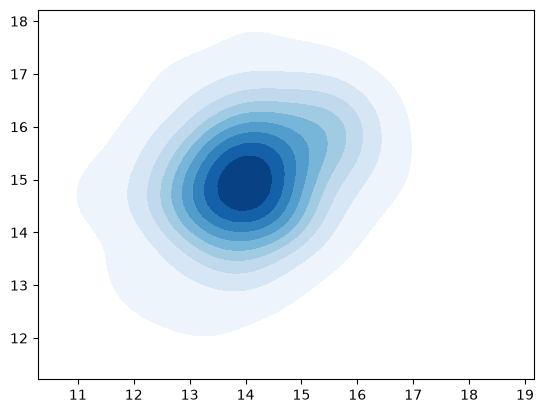

In [12]:
lo = np.percentile(X_train, 1, axis=0)
hi = np.percentile(X_train, 99, axis=0)

sns.kdeplot(x=X_train[:,0], y=X_train[:,1], cmap="Blues", fill=True)
plt.xlim(lo[0] - 1, hi[0] + 1)
plt.ylim(lo[1] - 1, hi[1] + 1)
plt.show()


### custom contourplot

[(0.0, 35.0),
 (0.0, 35.0),
 Text(0.5, 0, 'Latency (ms)'),
 Text(0, 0.5, 'Throughput (mb/s)'),
 Text(0.5, 1.0, 'The Gaussian contours of the distribution fit to the dataset')]

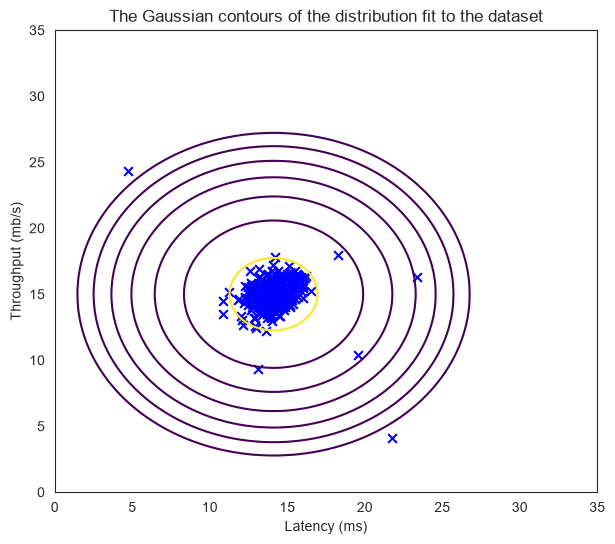

In [13]:
# 1. Fit the Gaussian (diagonal covariance = independent features)
mu = X_train.mean(axis=0)
var = X_train.var(axis=0)
dist = multivariate_normal(mean=mu, cov=np.diag(var))


# 2. Evaluate the density on a fine grid
xx, yy = np.meshgrid(np.linspace(0, 35, 400), np.linspace(0, 35, 400))
Z = dist.pdf(np.dstack([xx, yy]))

# 3. Plot
sns.set_style("white")
fig, ax = plt.subplots(figsize=(7, 6))

levels = 10.0 ** np.arange(-20, 0, 3)
ax.contour(xx, yy, Z, levels=levels, cmap="viridis")

sns.scatterplot(x=X_train[:,0], y=X_train[:,1], marker="x", color="blue",
                s=40, linewidth=1.5, ax=ax)

ax.set(xlim=(0, 35), ylim=(0, 35),
       xlabel="Latency (ms)", ylabel="Throughput (mb/s)",
       title="The Gaussian contours of the distribution fit to the dataset")


### choose treshold

In [14]:
p_val = multivariate_gaussian(X_val, mu, var)
step_size = (max(p_val) - min(p_val)) / 1000
np.arange(min(p_val), max(p_val), step_size)
epsilon = np.arange(min(p_val), max(p_val), step_size)[0]
y_val[p_val<epsilon].shape[0]
np.sum(p_val[y_val==1]<epsilon) #tp
np.sum(p_val[y_val==0]<epsilon) #fp
np.sum(p_val[y_val==1]>epsilon) #fn

np.int64(8)

In [15]:
def select_threshold(y_val, p_val): 
    """
    Finds the best threshold to use for selecting outliers 
    based on the results from a validation set (p_val) 
    and the ground truth (y_val)
    
    Args:
        y_val (ndarray): Ground truth on validation set
        p_val (ndarray): Results on validation set
        
    Returns:
        epsilon (float): Threshold chosen 
        F1 (float):      F1 score by choosing epsilon as threshold
    """ 

    best_epsilon = 0
    best_F1 = 0
    F1 = 0
    
    step_size = (max(p_val) - min(p_val)) / 1000
    
    for epsilon in np.arange(min(p_val), max(p_val), step_size):
    
        
        tp = np.sum(p_val[y_val==1]<epsilon) #true positive
        fp = np.sum(p_val[y_val==0]<epsilon) #false positive
        fn = np.sum(p_val[y_val==1]>epsilon) #false negative
        
        if tp == 0:          
            continue
        prec = tp/(tp + fp)
        rec = tp/(tp + fn)
        
        F1 = (2*prec*rec)/(prec+rec)
        
        
        if F1 > best_F1:
            best_F1 = F1
            best_epsilon = epsilon
        
    return best_epsilon, best_F1

In [16]:
p_val = multivariate_gaussian(X_val, mu, var)
epsilon, F1 = select_threshold(y_val, p_val)

print('Best epsilon found using cross-validation: %e' % epsilon)
print('Best F1 on Cross Validation Set: %f' % F1)

Best epsilon found using cross-validation: 8.990853e-05
Best F1 on Cross Validation Set: 0.875000


In [80]:
epsilon

np.float64(8.990852779269495e-05)

In [81]:
p[:5]

array([0.06470829, 0.05030417, 0.07245035, 0.05031575, 0.06368497])

In [17]:
# Find the outliers in the training set 
outliers = p < epsilon
outliers[:5]

array([False, False, False, False, False])

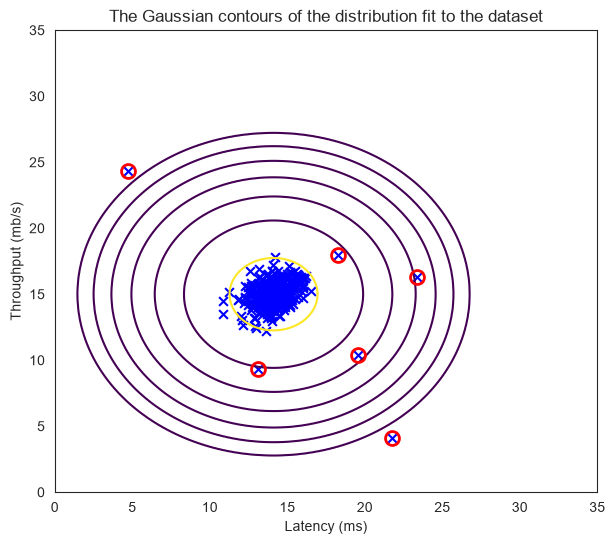

In [ ]:

# Visualize the fit
# visualize_fit(X_train, mu, var)

# 1. Fit the Gaussian (diagonal covariance = independent features)
mu = X_train.mean(axis=0)
var = X_train.var(axis=0)
dist = multivariate_normal(mean=mu, cov=np.diag(var))


# 2. Evaluate the density on a fine grid
xx, yy = np.meshgrid(np.linspace(0, 35, 400), np.linspace(0, 35, 400))
Z = dist.pdf(np.dstack([xx, yy]))

# 3. Plot
sns.set_style("white")
fig, ax = plt.subplots(figsize=(7, 6))

levels = 10.0 ** np.arange(-20, 0, 3)
ax.contour(xx, yy, Z, levels=levels, cmap="viridis")

sns.scatterplot(x=X_train[:,0], y=X_train[:,1], marker="x", color="blue",
                s=40, linewidth=1.5, ax=ax)

ax.set(xlim=(0, 35), ylim=(0, 35),
       xlabel="Latency (ms)", ylabel="Throughput (mb/s)",
       title="The Gaussian contours of the distribution fit to the dataset")

# Draw a red circle around those outliers
plt.plot(X_train[outliers, 0], X_train[outliers, 1], 'ro',
         markersize= 10,markerfacecolor='none', markeredgewidth=2)

## High dimensional dataset

In [18]:
X_train_high = np.load("data/X_part2.npy")
X_val_high = np.load("data/X_val_part2.npy")
y_val_high = np.load("data/y_val_part2.npy")

In [25]:
print('X_train_high:', X_train_high.shape)
print('X_val_high:', X_val_high.shape)
print('y_val_high:', y_val_high.shape)

X_train_high: (1000, 11)
X_val_high: (100, 11)
y_val_high: (100,)


In [23]:
mu_high, var_high = estimate_gaussian(X_train_high)

In [33]:
from scipy.stats import multivariate_normal

p_high = multivariate_normal(mu_high, var_high).pdf(X_train_high)


In [34]:
from sklearn.metrics import f1_score

In [36]:
p_val_high = multivariate_normal(mu_high, var_high).pdf(X_val_high)
epsilon_high, F1_high = select_threshold(y_val_high, p_val_high)

In [40]:
F1_high

np.float64(0.6153846153846154)

In [39]:
print('Best epsilon found using cross-validation: %e'% epsilon_high)
print('Best F1 on Cross Validation Set:  %f'% F1_high)
print('# Anomalies found: %d'% sum(p_high < epsilon_high))

Best epsilon found using cross-validation: 1.377229e-18
Best F1 on Cross Validation Set:  0.615385
# Anomalies found: 117


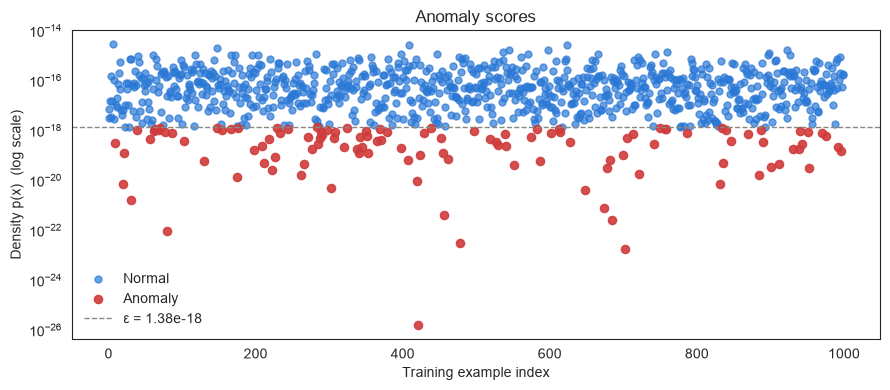

In [51]:
plt.figure(figsize=(9, 4))

idx = np.arange(len(p_high))
is_anomaly = p_high < epsilon_high

plt.scatter(idx[~is_anomaly], p_high[~is_anomaly],
            c='#2a78d6', s=25, label='Normal', alpha=0.7)
plt.scatter(idx[is_anomaly], p_high[is_anomaly],
            c='#d03b3b', s=35, label='Anomaly', alpha=0.9)
plt.axhline(epsilon_high, color='#898781', linestyle='--', linewidth=1,
            label=f'ε = {epsilon_high:.2e}')

plt.yscale('log')
plt.xlabel('Training example index')
plt.ylabel('Density p(x)  (log scale)')
plt.title('Anomaly scores')
plt.legend(frameon=False)
plt.tight_layout()


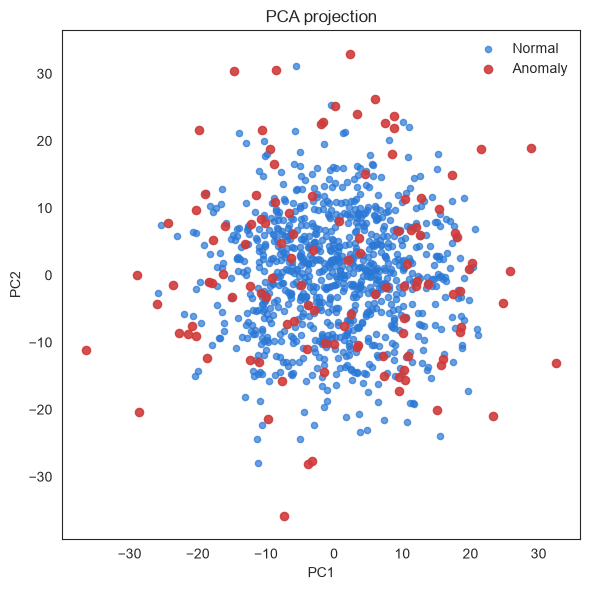

In [48]:
from sklearn.decomposition import PCA

Z = PCA(n_components=2).fit_transform(X_train_high)
outliers_high = p_high < epsilon_high

plt.figure(figsize=(6, 6))
plt.scatter(Z[~outliers_high, 0], Z[~outliers_high, 1],
            c='#2a78d6', s=20, label='Normal', alpha=0.7)
plt.scatter(Z[outliers_high, 0], Z[outliers_high, 1],
            c='#d03b3b', s=35, label='Anomaly', alpha=0.9)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA projection')
plt.legend(frameon=False)
plt.tight_layout()
